# MNE로 로우데이터 로딩부터 전처리까지, 가능하면 더 나아가기기

[순서]
1. 원시 데이터에서 이벤트 구문 분석
https://mne.tools/stable/auto_tutorials/intro/20_events_from_raw.html

# Data loading (데이터 불러오기+ 시각화; 발작 시점의 뇌파 비교)

In [ ]:
# 파이썬 모듈 로딩과 함께 (RAM 메모리 절약 위해) raw 객체 60초로 분할.

import os
import numpy as np
import mne


''' 원문의 mne 자체 제공 샘플 데이터 불러오는 코드.
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
'''

# chb01 환자의 3번 파일; chb01_03.edf (seizure 있음)
raw = mne.io.read_raw_edf(
    "/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf",
    preload=True,
    verbose=False
)
raw.crop(tmax=3599).load_data() #처음 0초 ~ 3599초.(실제로 59분 59.99xx초라서 60분 꽉 채우면 인식 오류 생김.)

/tmp/ipykernel_329390/1840515159.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


<RawEDF | chb01_03.edf, 23 x 921345 (3599.0 s), ~161.7 MiB, data loaded>

이벤트 및 주석(Annotations) 데이터 구조

주석은 뇌파 기록 중 시간의 매핑과 그 시간에 발생한 이벤트에 대한 설명 제공.

STIM channel?

stimulate channel; EEG, MEG 또는 기타 센서로부터 신호를 수신하지 않는 채널. 대신, STIM 채널은 전압(DC pulse)을 기록하며, 이 펄스는 자극의 시작이나 피험자의 버튼 누름 반응과 같은 실험 사건에 시간적으로 고정됨.
이러한 펄스가 실험 사건에 시간적으로 고정되지 않고, 다음 시행에서 발생할 자극(또는 실험 조건)의 조건을 나타내기 위해 trial 사이에 발생할 수도 있음.

[단! chb db의 경우 이런 STIM 채널에 대한 정보 없음.]
ㄴ 순수하게 뇌파 기록만 하고 발작 기간으로 보이는 부분은 연구진 재량으로 직접 기록했으니까.

###
chb01_03 발작 시기.
Seizure Start Time: 2996 seconds >> 49분 56초
Seizure End Time: 3036 seconds >> 50분36초  (40초 지속)

바로 밑 코드는 전체 60분(3599초) 중 발작 발생 trial을 시각화하여 비발작 파형과의 비교 목적을 담음.
※ 최소 범위 2980~3060초 (80초) + 진폭 120 μV(=120e-6) -> 잘 보임.

1.
https://synapse.koreamed.org/upload/synapsedata/pdfdata/0055jkna/jkna-58-76.pdf
진폭은 20 μV 이하인 경우 저진폭, 20~70 μV는 중진폭, 70 μV 이상인 경우 고진폭으로 표기한다. 
2.
https://jknpa.org/doix.php?id=10.4306/jknpa.2019.58.2.76
진폭 분류로 해석할 때는 진폭의 하단값과 상단값을 알아야 한다. 다음과 같은 이상이 있다면 확인이 필요하다; __하단이 5 µV 이상, 상단이 10 µV 이상이면 정상이며__, 하단이 5 µV 이하, 상단이 10 µV 이상이면 중등도의 비정상 상태로 판단한다. 또한 하단이 5 µV 미만, 상단이 10 µV 미만이면 중증 비정상 상태로 판단한다.


그러나 작은 규격의 그래프에 장시간의 epoch이 담긴 trial을 쉽게 확인하려면(60~180초) 진폭의 척도를 매우 크게(예:120 μV) 설정해야 됨.
또, 발작이 일어나는 시점에서 이런 파형의 진폭이 아주 크게 튀는데 상하 상관 없이 70µV 이상으로 peak가 발생함. 원래 뇌전증이란 병이 이런 것인지 다시 알아봐야겠다.

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


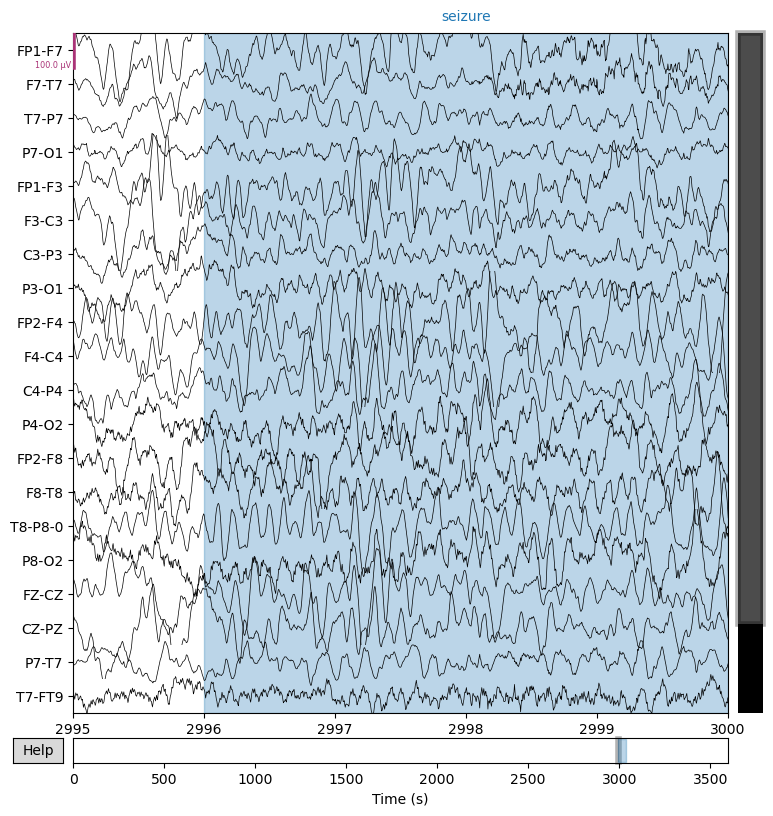

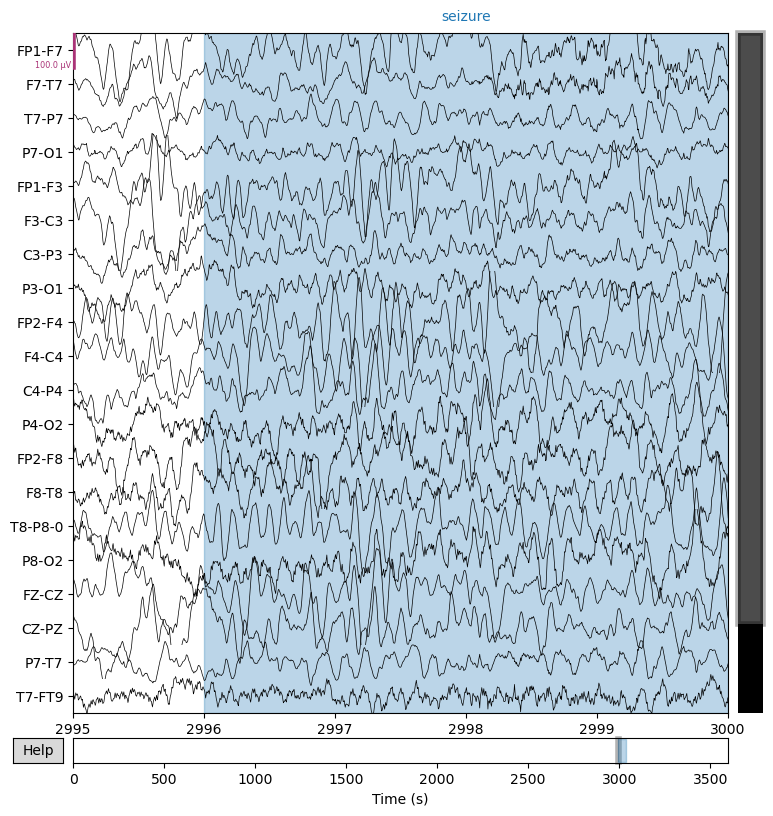

In [ ]:
#대안; EEG 신호 시각화 >>> 전체 or 특정 채널 

# 이벤트 채널 종류 확인
print(raw.info['ch_names'])  # 사용 가능한 채널 목록 확인

#EEG 신호 시각화 (특정 채널만 또는 전체)
raw.copy().pick('eeg').plot(start=2995, duration=5, scalings=dict(eeg=50e-6)) 

# scalings: dict(eeg=값)으로 수동 진폭 설정 (40e-6 = 40 μV ; 4 / 10^6)

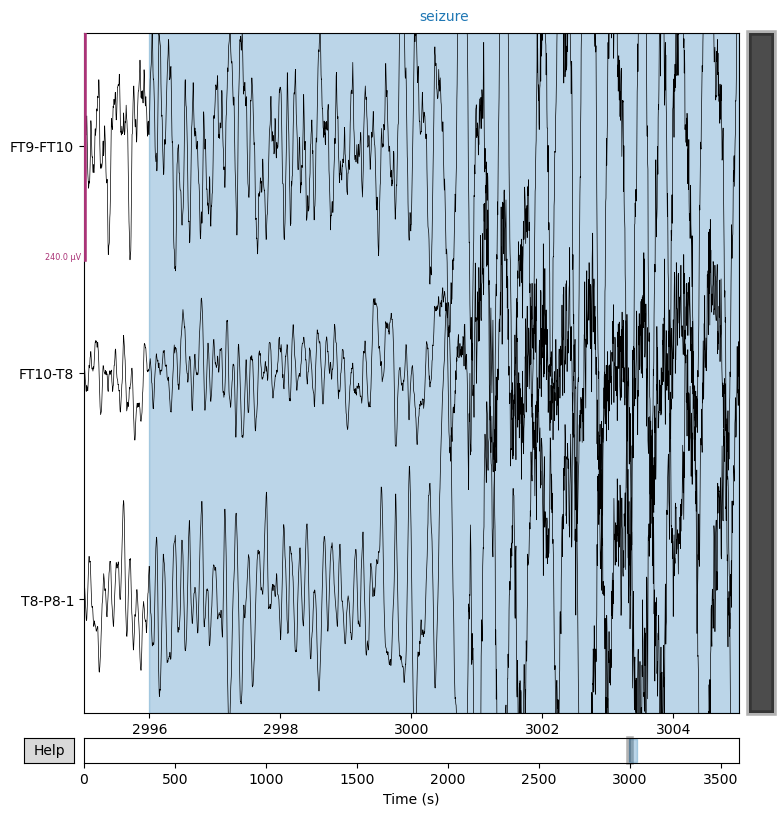

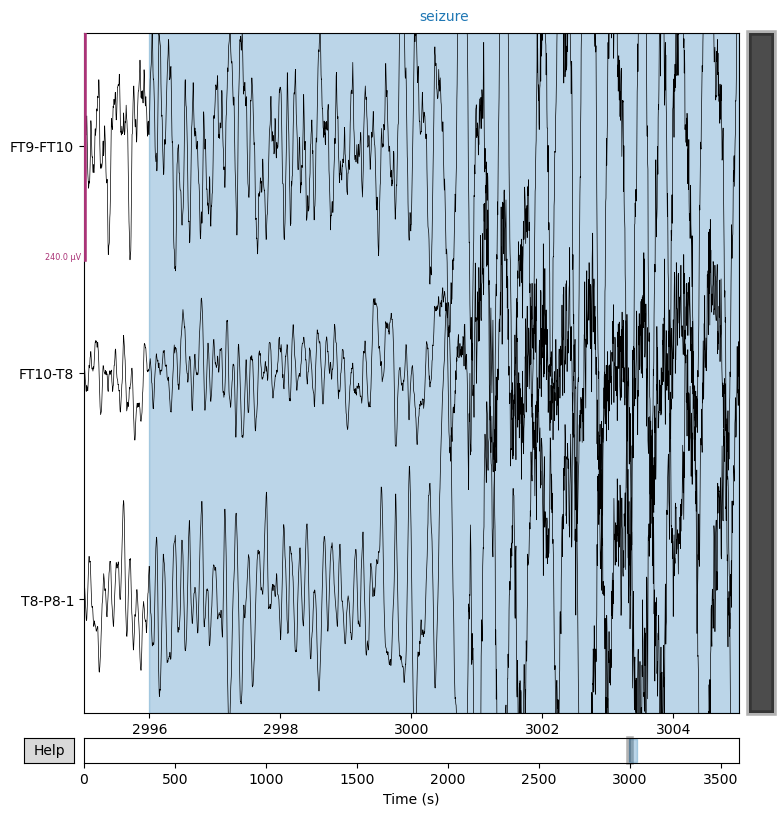

In [144]:
# 또는 채널명을 직접 선택해서 시각화; 전체 채널 그래프 중 하위 3가지가 잘림...
raw.copy().pick(['FT9-FT10', 'FT10-T8', 'T8-P8-1']).plot(start=2995, duration=10, scalings=dict(eeg=120e-6))

# 내장된 이벤트를 주석으로 읽기 >>> .seizure 표시하기?
(원문)
일부 EEG/MEG 시스템은 이벤트가 하나 이상의 STIM 채널에 펄스 형태로 저장되는 대신 별도의 데이터 배열에 저장되는 파일을 생성합니다. 예를 들어, EEGLAB 형식은 이벤트를 [.set] 파일에 배열 모음으로 저장합니다. 이러한 파일을 읽을 때 MNE-Python은 저장된 이벤트를 자동으로 Annotations 객체로 변환하여 Raw 객체의 주석 속성으로 저장합니다.

In [ ]:
''' 냅다 따라하고 억지로 코드 고친 것, 폐기
eeglab_raw_file = mne.io.read_raw_eeglab(
    "/home/media/data2/user_home/khj/KHJworks/EEGstudy/EESNN/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf.seizures",
    preload=True,
    verbose=False
)
eeglab_raw = mne.io.read_raw_eeglab(eeglab_raw_file)
print(eeglab_raw.annotations)
'''

>>>
[RuntimeError]: For EEGLAB I/O to work, the module pymatreader is needed, but it could not be imported. Use the following installation method appropriate for your environment:
...
    324     '''
--> 325     super().__init__(mat_stream, *args, **kwargs)
    326     self._matrix_reader = None

[TypeError]: MatFileReader.__init__() got an unexpected keyword argument 'uint16_codec'

결론: unit16 같은 거 여기 없다. 걍 다른 것을 하자.

>>> # 해결책: seizure 구간 수동으로 주석 달기

# 주석 수동으로 만들기

In [115]:
# 1. 모듈, 로우데이터 로드 (생략)
raw

<RawEDF | chb01_03.edf, 23 x 921345 (3599.0 s), ~161.7 MiB, data loaded>

In [119]:
# 2. 발작 시점 지정

seizure_onset = 2996.0 
seizure_end = 3036.0

# 3. 주석 생성
annot = mne.Annotations(
    onset = [seizure_onset], 
    duration = [seizure_end - seizure_onset],
    description= 'seizure'
)

In [120]:
# 4. raw 객체에 주석 붙이기
raw.set_annotations(annot)

<RawEDF | chb01_03.edf, 23 x 921345 (3599.0 s), ~161.7 MiB, data loaded>

# annot -> event 변환 + 시각화
이래야 epoching에 쓸 수 있음

In [ ]:
# Annotations 객체에서 이벤트 추출
# 주석의 description을 기반으로 이벤트 생성
event_dict = mne.events_from_annotations(raw)           # 인수 events 삭제; 여기서는 쓸모없는것같음
print(event_dict)       # {'seizure': 1}
#print(events[:5])       # [시작 샘플,   0,    이벤트 ID] 형태

Used Annotations descriptions: ['seizure']
(array([[766976,      0,      1]]), {'seizure': 1})


In [ ]:
'''
# event -> annot로 돌아가기
annot_back = mne.annotations_from_events(
    events=events,
    event_desc=event_dict,
    sfreq=raw.info["sfreq"],
    orig_time=raw.info["meas_date"],
)
raw.set_annotations(annot_back)
'''

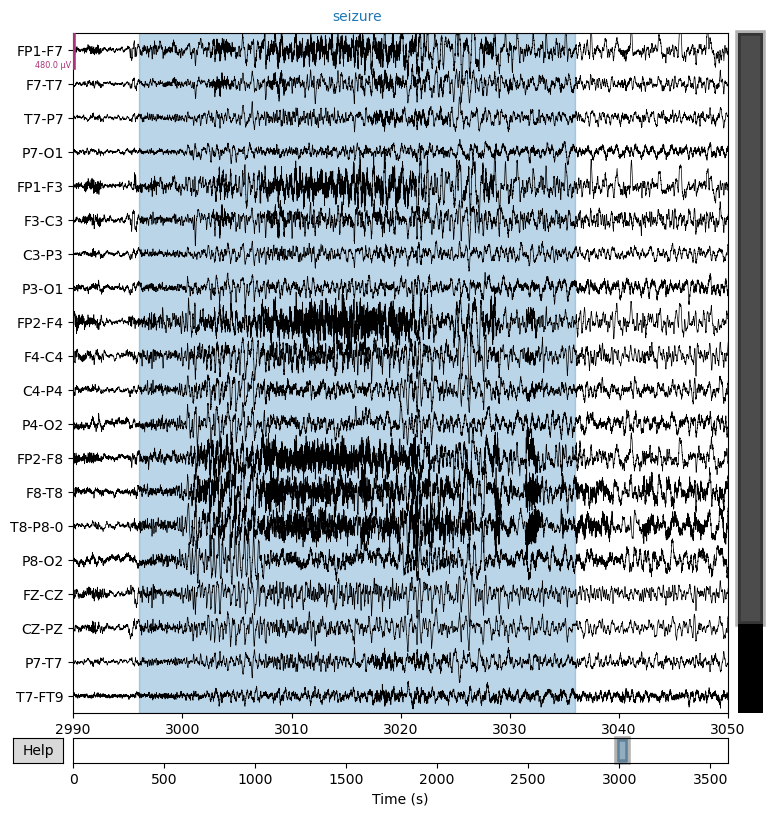

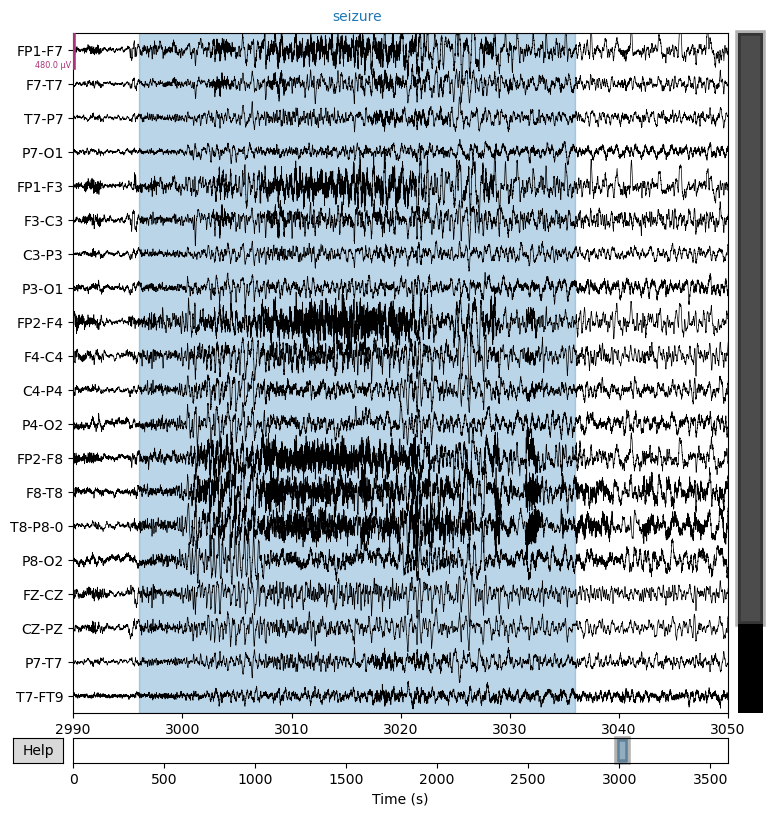

In [135]:
# 시각화 (발작 주석 표시됨)
raw.plot(start=2990, duration=60, scalings=dict(eeg=240e-6))